In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt


In [ ]:

#Calculate the Sprint Pose Fitness Score (SPFS)

compare_dir = '../comparison_final'
kp = '/keypoints'
agl = '/angles'

# Load specific CSVs from the keypoints folder into a dictionary
keypoints_files = {
    'blurry_errors': f'{compare_dir}{kp}/all/info/errors/dataframe/blurry_errors.csv',
    'blurry_occluded_errors': f'{compare_dir}{kp}/all/info/errors/dataframe/blurry_occluded_errors.csv',
    'normal_errors': f'{compare_dir}{kp}/all/info/errors/dataframe/normal_errors.csv',
    'occluded_errors': f'{compare_dir}{kp}/all/info/errors/dataframe/occluded_errors.csv'
}

# Load specific CSVs from the keypoints folder into a dictionary
angles_files = {
    'blurry_errors': f'{compare_dir}{agl}/all/info/errors/dataframe/blurry_errors.csv',
    'blurry_occluded_errors': f'{compare_dir}{agl}/all/info/errors/dataframe/blurry_occluded_errors.csv',
    'normal_errors': f'{compare_dir}{agl}/all/info/errors/dataframe/normal_errors.csv',
    'occluded_errors': f'{compare_dir}{agl}/all/info/errors/dataframe/occluded_errors.csv'
}

keypoints_dfs = {key: pd.read_csv(path) for key, path in keypoints_files.items()}
angles_dfs = {key: pd.read_csv(path) for key, path in angles_files.items()}


In [ ]:
print(keypoints_dfs['blurry_errors'])

                frame     keypoint  mediapipe_error  mmpose_error  yolo_error  \
0   maxV_far_frame_30    left_knee              NaN      2.292254         NaN   
1   maxV_far_frame_30   left_ankle              NaN     12.570562         NaN   
2   maxV_far_frame_30   left_wrist              NaN      5.999251         NaN   
3   maxV_far_frame_30    left_feet              NaN     11.009946         NaN   
4   maxV_far_frame_35  right_ankle              NaN     11.652583         NaN   
..                ...          ...              ...           ...         ...   
79     accel_frame_69   left_wrist        96.500693     29.643878  170.924675   
80     accel_frame_69  right_wrist        22.242403     13.367099   15.511296   
81     accel_frame_69   right_knee       162.096741     12.545399   26.683125   
82     accel_frame_69  right_ankle       265.182241     22.957306   33.477626   
83     accel_frame_69   right_feet       336.100111     67.726042         NaN   

    normalized_mediapipe_er

In [ ]:
FRAMES = {
    "close": [#Chosen based on identical sprint motion, only difference is the distance to the camera
        "maxV_close_frame_7",
        "maxV_close_frame_15"
    ],
    "far": [
        "maxV_far_frame_30",
        "maxV_far_frame_35",
        "maxV_far_frame_40"
    ],
    "accel": [#Only cared about making the avg bbox as close as possible to eachother between the phases
        "accel_frame_57",
        "accel_frame_59",
        "accel_frame_61",
        "accel_frame_67",
        "accel_frame_69"
    ],
    "maxV": [
        "maxV_close_frame_12",
        "maxV_close_frame_17",
        "maxV_close_frame_18",
        "maxV_close_frame_19"
    ],
    "close/maxV": [
        "maxV_close_frame_11"
    ]
}

def convert_keypoint_name(keypoint):
    # Split the string by underscores, capitalize each word, and join with a space
    return " ".join(word.capitalize() for word in keypoint.split("_"))

def calculate_weighted_score(error, weight):
    if pd.isna(error):
        return 0
    return weight / (1 + error)

def calculate_unweighted_score(error):
    if pd.isna(error):
        return 0
    return 1 / (1 + error)


def get_phase(name):
    for phase, frames in FRAMES.items():
        if name in frames:
            return phase

def process_row(row, pose, type, weight, status):
    return {
        'Type': type,
        'Phase': get_phase(row['frame']),
        'Name': convert_keypoint_name(row['keypoint']),  
        'Weighted Score': calculate_weighted_score(row[pose], weight), 
        'Unweighted Score': calculate_unweighted_score(row[pose]), 
        'Status': status,
        'Weight': weight
    }

In [ ]:
mediapipe_scores = pd.DataFrame(columns = ['Type', 'Phase', 'Name', 'Weighted Score', 'Unweighted Score', 'Status', 'Weight'])
mmpose_scores = pd.DataFrame(columns = ['Type', 'Phase', 'Name', 'Weighted Score', 'Unweighted Score', 'Status', 'Weight'])
yolo_scores = pd.DataFrame(columns = ['Type', 'Phase', 'Name', 'Weighted Score', 'Unweighted Score', 'Status', 'Weight'])

In [37]:
ERROR_TYPES = ['blurry_errors', 'blurry_occluded_errors', 'normal_errors', 'occluded_errors']

SCORES = ['Weighted Score', 'Unweighted Score']

for type in ERROR_TYPES:
    weight = 0
    status = ''
    if type == 'normal_errors':
        weight = 1
        status = 'Normal'
    elif type == 'occluded_errors':
        weight = 1.5
        status = 'Occluded'
    elif type == 'blurry_errors':
        weight = 1.75
        status = 'Blurry'
    elif type == 'blurry_occluded_errors':
        weight = 2
        status = 'Blurry and Occluded'


    if weight == 0 or status == '':
        raise ValueError(f"Something went wrong with the weight or status for {type}")  
    
    keypoints_df = keypoints_dfs[type]
    angles_df = angles_dfs[type]

    # Calculate the SPFS
    # Apply the function to each row and append the results to scores_df
    processed_mediapipe_joints = keypoints_df.apply(lambda row: process_row(row, 'normalized_mediapipe_error', 'Joint', weight, status), axis=1)
    processed_mmpose_joints = keypoints_df.apply(lambda row: process_row(row, 'normalized_mmpose_error', 'Joint', weight, status), axis=1)
    processed_yolo_joints = keypoints_df.apply(lambda row: process_row(row, 'normalized_yolo_error', 'Joint', weight, status), axis=1)

    processed_mediapipe_angles = angles_df.apply(lambda row: process_row(row, 'normalized_mediapipe_error', 'Angles', weight, status), axis=1)
    processed_mmpose_angles = angles_df.apply(lambda row: process_row(row, 'normalized_mmpose_error', 'Angles', weight, status), axis=1)
    processed_yolo_angles = angles_df.apply(lambda row: process_row(row, 'normalized_yolo_error', 'Angles', weight, status), axis=1)

    mediapipe_scores = pd.concat([mediapipe_scores, pd.DataFrame(processed_mediapipe_joints.tolist())], ignore_index=True)
    mmpose_scores = pd.concat([mmpose_scores, pd.DataFrame(processed_mmpose_joints.tolist())], ignore_index=True)
    yolo_scores = pd.concat([yolo_scores, pd.DataFrame(processed_yolo_joints.tolist())], ignore_index=True)

    mediapipe_scores = pd.concat([mediapipe_scores, pd.DataFrame(processed_mediapipe_angles.tolist())], ignore_index=True)
    mmpose_scores = pd.concat([mmpose_scores, pd.DataFrame(processed_mmpose_angles.tolist())], ignore_index=True)
    yolo_scores = pd.concat([yolo_scores, pd.DataFrame(processed_yolo_angles.tolist())], ignore_index=True)

**WES_point**	Score per joint or angle (per frame)	Analyze specific joints like knees or hips<br><br>
**WES_frame**	Average score of all joints/angles in a single frame	Evaluate frame-level pose quality<br><br>
**WES_phase**	Average over all frames within a sprint phase (e.g. Accel)	Compare Accel vs MaxV<br><br>
**WES_env**	Average over camera distance (e.g. Close vs Far)	Test environmental robustness<br><br>
**WES_condition**	Average based on blur/occlusion condition	Impact of blur/occlusion on accuracy<br><br>
**WES_model**	Average across all predictions from one model	Compare MediaPipe vs YOLO vs MMPose<br><br>
**WES_joint_type**	Avg score for a specific joint (e.g. all left ankles)	Identify which joints suffer most in poor conditions<br><br>

In [38]:
categories = {
    "WES_phase": "Phase", #Sum as the same number of points to be compared
    "WES_status": "Status", #Average as different number of points to be compared
    "WES_type": "Type", #Average as different number of points to be compared
    "WES_joint_angle": "Name" #Average as different number of points to be compared
}

# Add logic to ignore the "close/maxV" phase and aggregate it separately
def calculate_sums_with_ignore(scores_df, category_key, ignore_phase="close/maxV"):
    if category_key == "WES_phase":
        filtered_df = scores_df[scores_df['Phase'] != ignore_phase]
        ignored_df = scores_df[scores_df['Phase'] == ignore_phase]
        ignored_df_close = ignored_df.copy()
        ignored_df_close['Phase'] = "close"
        ignored_df_maxV = ignored_df.copy()
        ignored_df_maxV['Phase'] = "maxV"
        filtered_df = pd.concat([filtered_df, ignored_df_close, ignored_df_maxV], ignore_index=True)
        return filtered_df.groupby(categories[category_key])[SCORES].mean()
    elif category_key == "WES_joint_angle":
        # Combine left and right sides for joint/angle names
        scores_df['Combined Name'] = scores_df['Name'].replace({
            'Left Ankle': 'Ankle',
            'Right Ankle': 'Ankle',
            'Left Ankle Angle': 'Ankle Angle',
            'Right Ankle Angle': 'Ankle Angle',

            'Left Knee': 'Knee',
            'Right Knee': 'Knee',
            'Left Knee Angle': 'Knee Angle',
            'Right Knee Angle': 'Knee Angle',

            'Left Hip': 'Hip',
            'Right Hip': 'Hip',
            'Left Hip Angle': 'Hip Angle',
            'Right Hip Angle': 'Hip Angle',

            'Left Shoulder': 'Shoulder',
            'Right Shoulder': 'Shoulder',
            'Left Shoulder Angle': 'Shoulder Angle',
            'Right Shoulder Angle': 'Shoulder Angle',

            'Left Elbow': 'Elbow',
            'Right Elbow': 'Elbow',
            'Left Elbow Angle': 'Elbow Angle',
            'Right Elbow Angle': 'Elbow Angle',

            'Left Wrist': 'Wrist',
            'Right Wrist': 'Wrist',
            
            'Left Feet': 'Feet',
            'Right Feet': 'Feet'
        })
        return scores_df.groupby('Combined Name')[SCORES].mean()
    else:
        return scores_df.groupby(categories[category_key])[SCORES].mean()
    


for category in categories:
    print(f"Category: {category}")
    print("Mediapipe Scores:")
    print(calculate_sums_with_ignore(mediapipe_scores, category))
    print("\nMMPose Scores:")
    print(calculate_sums_with_ignore(mmpose_scores, category))
    print("\nYOLO Scores:")
    print(calculate_sums_with_ignore(yolo_scores, category))
    print("\n" + "-"*55 + "\n")

# Summation of everything 
print("Summation of Everything:")
print("Mediapipe Scores:")
print(mediapipe_scores[SCORES].mean())
print("\nMMPose Scores:")
print(mmpose_scores[SCORES].mean())
print("\nYOLO Scores:")
print(yolo_scores[SCORES].mean())
print("\n" + "="*55 + "\n")

Category: WES_phase
Mediapipe Scores:
       Weighted Score  Unweighted Score
Phase                                  
accel        0.782826          0.593769
close        0.513889          0.308287
far          0.000000          0.000000
maxV         0.614623          0.390919

MMPose Scores:
       Weighted Score  Unweighted Score
Phase                                  
accel        1.030599          0.774935
close        0.948709          0.566410
far          0.885913          0.719395
maxV         0.839816          0.544780

YOLO Scores:
       Weighted Score  Unweighted Score
Phase                                  
accel        0.563724          0.433918
close        0.676981          0.406285
far          0.000000          0.000000
maxV         0.648421          0.424281

-------------------------------------------------------

Category: WES_status
Mediapipe Scores:
                     Weighted Score  Unweighted Score
Status                                               
Blurry 

                     Weighted Score  Unweighted Score
Status                                               
Blurry                     1.012878          0.578787
Blurry and Occluded        1.042547          0.521273
Normal                     0.783143          0.783143
Occluded                   0.926103          0.617402

YOLO Scores:
                     Weighted Score  Unweighted Score
Status                                               
Blurry                     0.571702          0.326687
Blurry and Occluded        0.690005          0.345003
Normal                     0.346372          0.346372
Occluded                   0.520311          0.346874

-------------------------------------------------------

Category: WES_type
Mediapipe Scores:
        Weighted Score  Unweighted Score
Type                                    
Angles        0.461688          0.291737
Joint         0.560508          0.409576

MMPose Scores:
        Weighted Score  Unweighted Score
Type                  

Plotting Combined Scores for Category: Phase (Weighted Score)
Combining scores for WES_phase - Combined Scores - Phase (Weighted Score)


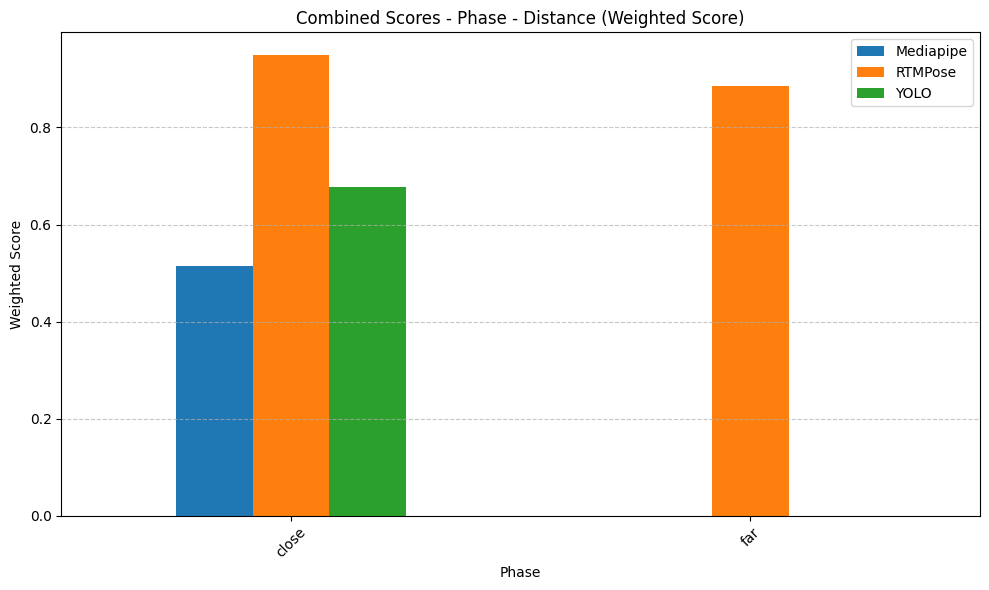

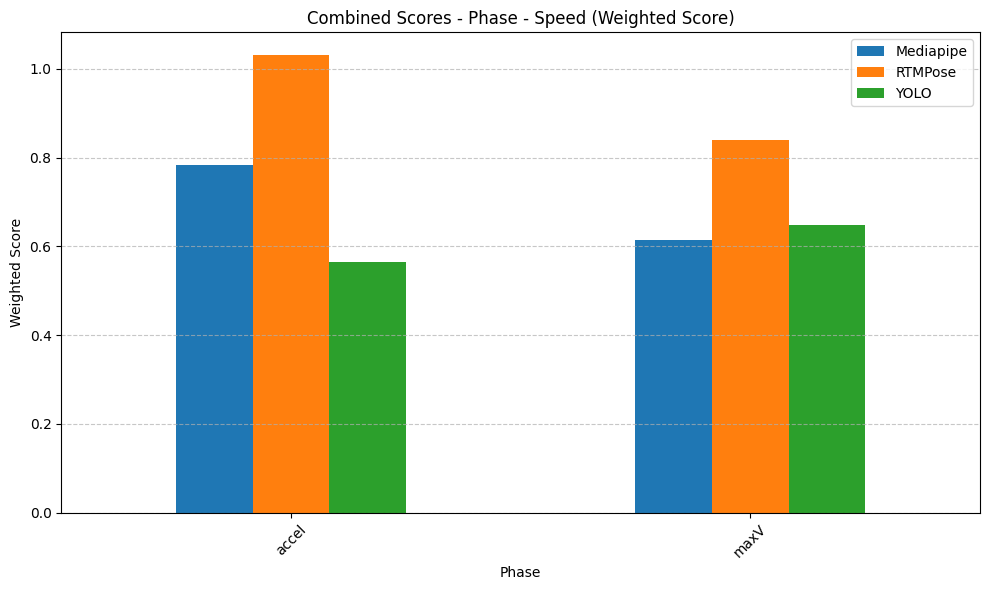

Plotting Combined Scores for Category: Phase (Unweighted Score)
Combining scores for WES_phase - Combined Scores - Phase (Unweighted Score)


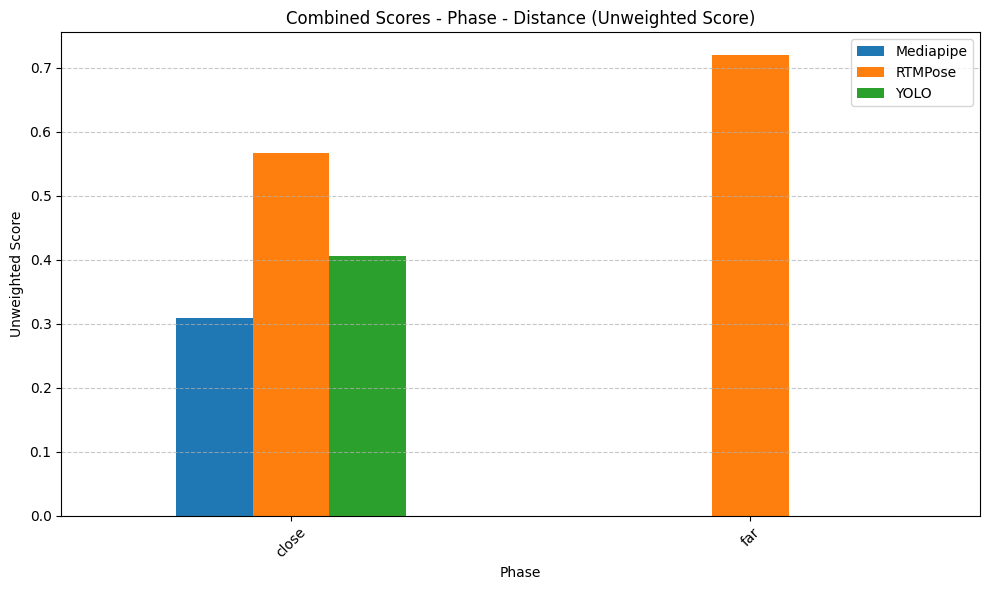

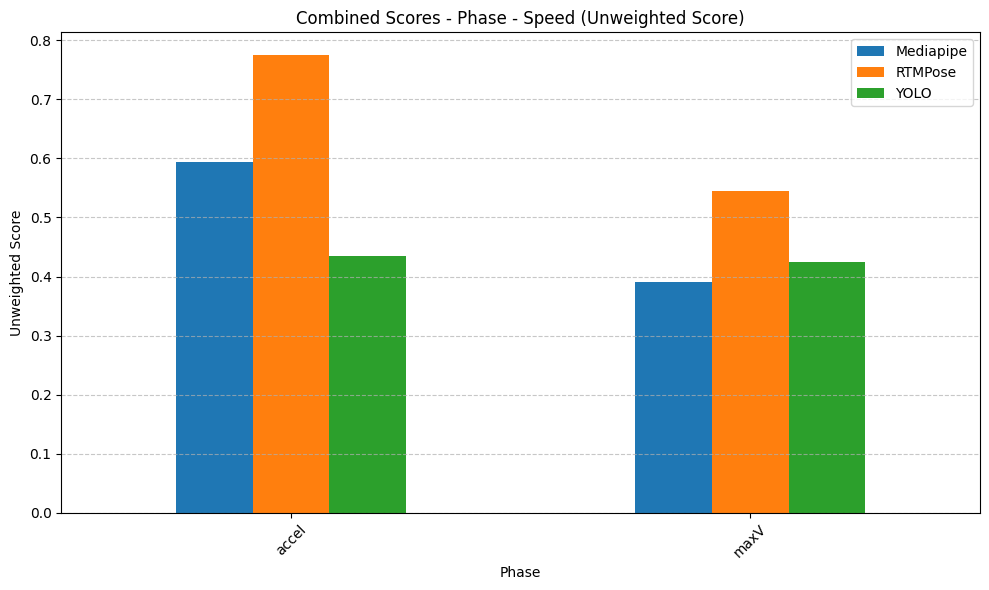

Plotting Combined Scores for Category: Status (Weighted Score)
Combining scores for WES_status - Combined Scores - Status (Weighted Score)


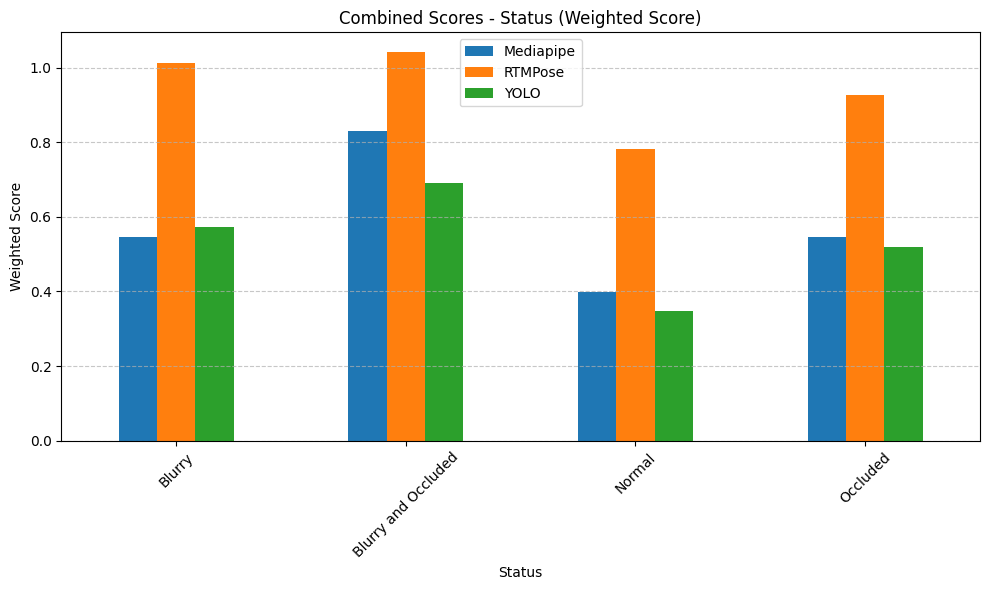

Plotting Combined Scores for Category: Status (Unweighted Score)
Combining scores for WES_status - Combined Scores - Status (Unweighted Score)


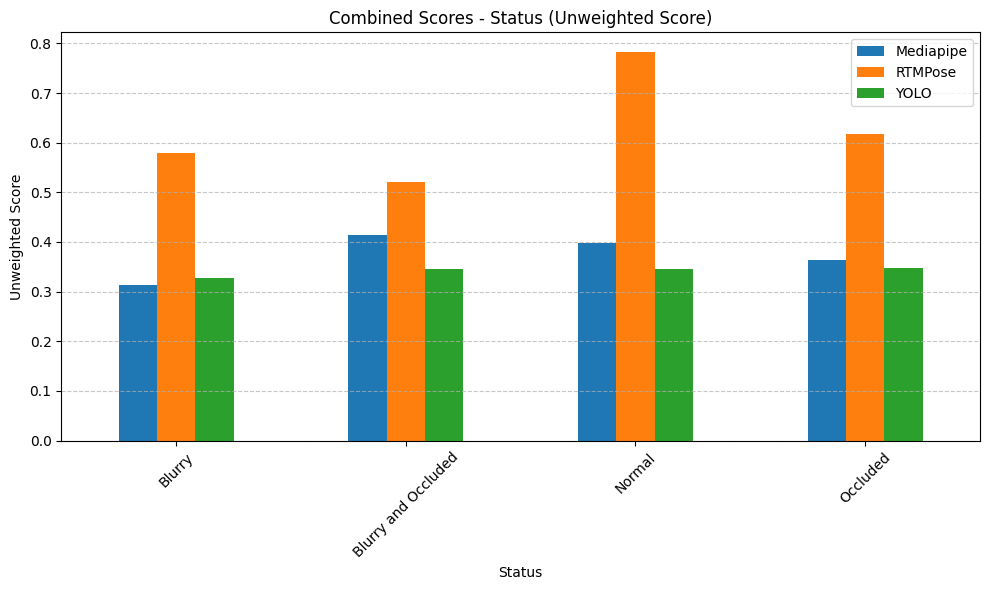

Plotting Combined Scores for Category: Type (Weighted Score)
Combining scores for WES_type - Combined Scores - Type (Weighted Score)


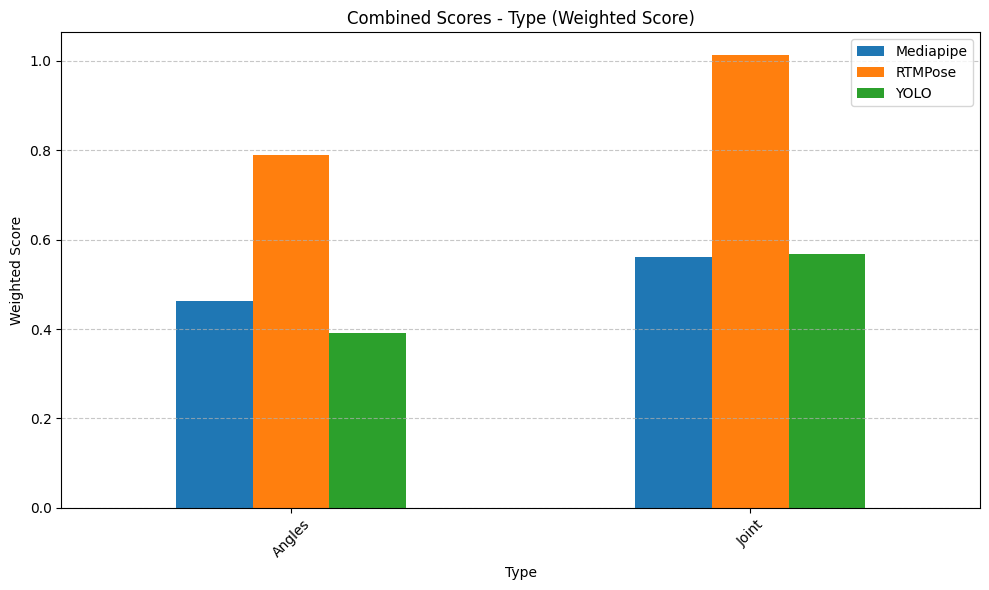

Plotting Combined Scores for Category: Type (Unweighted Score)
Combining scores for WES_type - Combined Scores - Type (Unweighted Score)


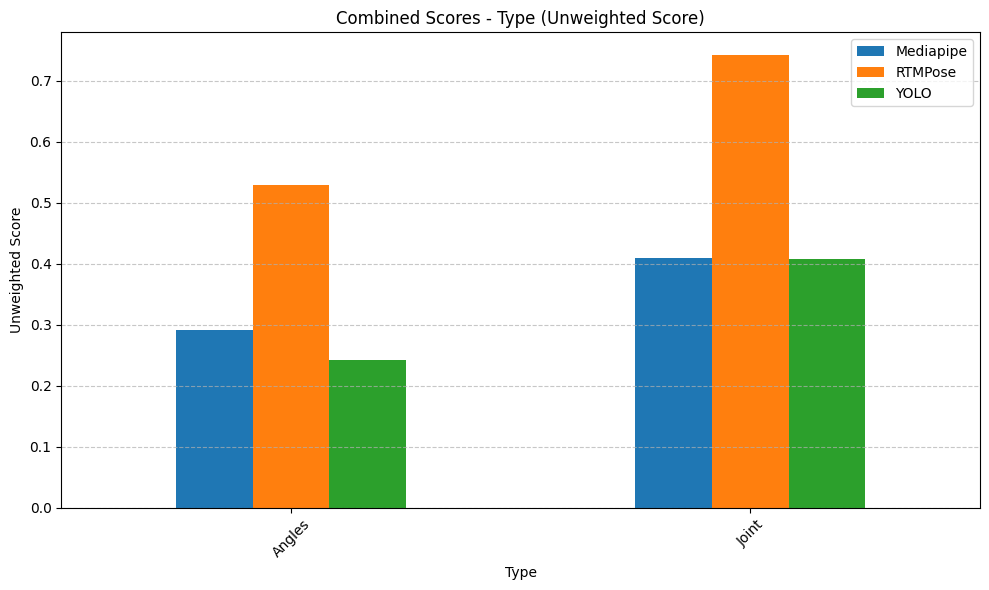

Plotting Combined Scores for Category: Name (Weighted Score)
Combining scores for WES_joint_angle - Combined Scores - Name (Weighted Score)


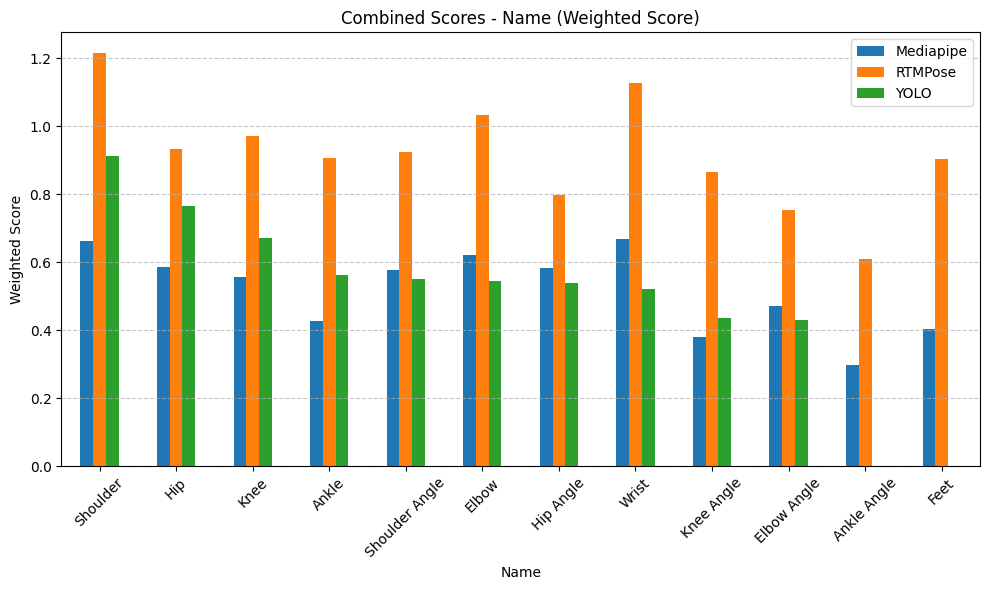

Plotting Combined Scores for Category: Name (Unweighted Score)
Combining scores for WES_joint_angle - Combined Scores - Name (Unweighted Score)


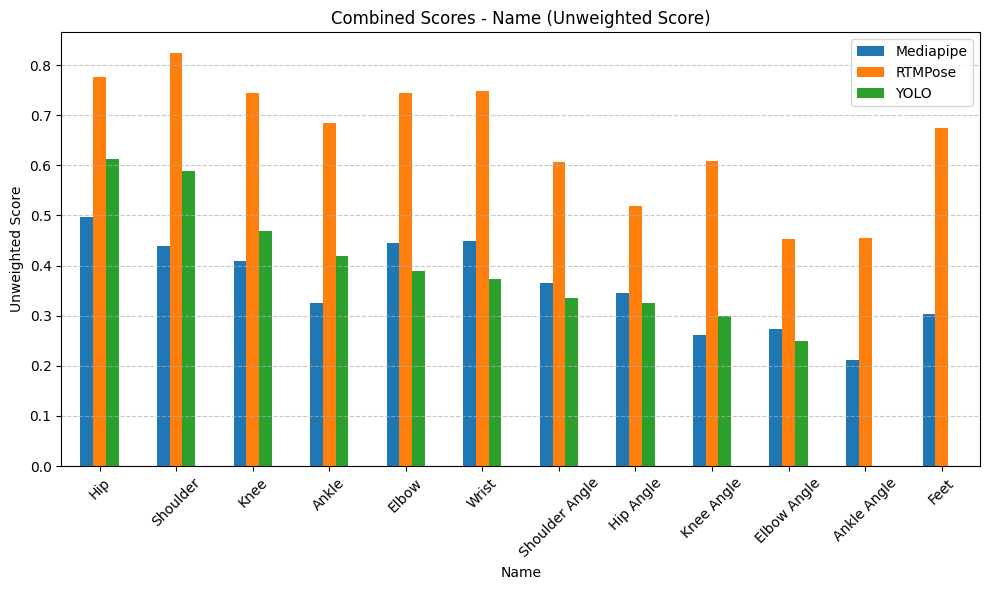

Plotting Combined Scores for All Categories (Unweighted Score):


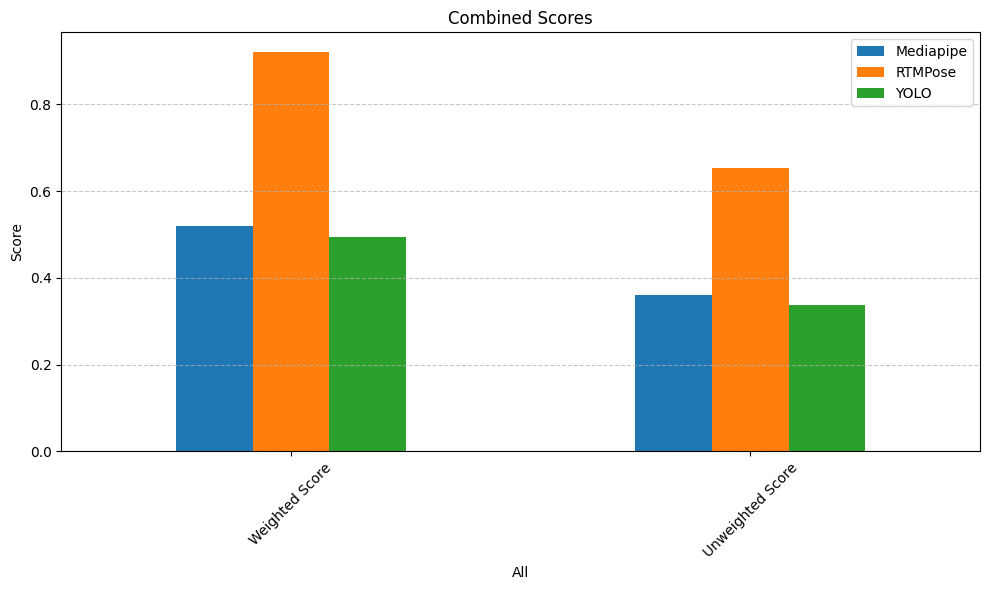

In [41]:
dir = '../results'
datapath = os.path.join(dir, 'S_data')
plotpath = os.path.join(dir, 'S_plots')

os.makedirs(dir, exist_ok=True)
os.makedirs(datapath, exist_ok=True)
os.makedirs(plotpath, exist_ok=True)

# Function to plot scores for a given category
def plot_scores(scores_df, category_key, title):
    if category_key not in ['Phase','All']:
        aggregated_scores = calculate_sums_with_ignore(scores_df, category_key)
        if category_key == "WES_phase":
            distance_aggregated_scores = aggregated_scores[aggregated_scores.index.isin(['close', 'far'])]
            speed_aggregated_scores = aggregated_scores[aggregated_scores.index.isin(['accel', 'maxV'])]
            plot_scores(distance_aggregated_scores, 'Phase', f"{title} - Distance")
            plot_scores(speed_aggregated_scores, 'Phase', f"{title} - Speed")
            return
        scores_df = aggregated_scores
    elif category_key == "All":
        scores_df = scores_df[SCORES].mean()

    filename = title.lower().replace(" - ", "_").replace(" ", "_")
    scores_df.to_csv(os.path.join(datapath, f'{filename}.csv'))

    scores_df.plot(kind='bar', figsize=(10, 6))
    plt.title(title)
    plt.ylabel('Scores')
    if category_key in ['Phase', 'All']:
        plt.xlabel(category_key)
    else:
        plt.xlabel(categories[category_key])
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(plotpath, f'{filename}.png'))
    plt.show()
    plt.close()


    

#Plot scores for each category and model
# for category in categories:
#     print(f"Plotting for Category: {categories[category]}")
#     print("Mediapipe Scores:")
#     plot_scores(mediapipe_scores, category, f"Mediapipe Scores - {categories[category]}")
#     print("\nMMPose Scores:")
#     plot_scores(mmpose_scores, category, f"MMPose Scores - {categories[category]}")
#     print("\nYOLO Scores:")
#     plot_scores(yolo_scores, category, f"YOLO Scores - {categories[category]}")

# print("Summation of Everything:")
# print("Mediapipe Scores:")
# plot_scores(mediapipe_scores, 'All', f"Mediapipe Scores - All")
# print("\nMMPose Scores:")
# plot_scores(mmpose_scores, 'All', f"MMPose Scores - All")
# print("\nYOLO Scores:")
# plot_scores(yolo_scores, 'All', f"YOLO Scores - All")

# Combine scores from all models into a single DataFrame for comparison
def combine_and_plot_all_models(category_key, title, score_type,combined_scores=None):

    if combined_scores is None:
        combined_scores = pd.DataFrame()
        print(f"Combining scores for {category_key} - {title} ({score_type})")
        combined_scores['Mediapipe'] = calculate_sums_with_ignore(mediapipe_scores, category_key)[score_type]
        combined_scores['RTMPose'] = calculate_sums_with_ignore(mmpose_scores, category_key)[score_type]
        combined_scores['YOLO'] = calculate_sums_with_ignore(yolo_scores, category_key)[score_type]
    
    if category_key == "WES_phase":
        distance_aggregated_scores = combined_scores[combined_scores.index.isin(['close', 'far'])]
        speed_aggregated_scores = combined_scores[combined_scores.index.isin(['accel', 'maxV'])]
        combine_and_plot_all_models('Phase',  f"{title} - Distance", score_type, distance_aggregated_scores)
        combine_and_plot_all_models('Phase',  f"{title} - Speed", score_type, speed_aggregated_scores)
        return

    filename = f"{title.lower().replace(' - ', '_').replace(' ', '_')}_{score_type.lower().replace(' ', '_')}"
    combined_scores.to_csv(os.path.join(datapath, f'{filename}.csv'))

    if category_key == "WES_joint_angle":
        combined_scores = combined_scores.sort_values(by='YOLO', ascending=False)

    combined_scores.plot(kind='bar', figsize=(10, 6))
        

    if score_type != "Score":
        plt.title(f"{title} ({score_type})")
    else:
        plt.title(title)
    plt.ylabel(score_type)

    if category_key in ['Phase', 'All']:
        plt.xlabel(category_key)
    else:
        plt.xlabel(categories[category_key])
    
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(plotpath, f'{filename}.png'))
    plt.show()
    plt.close()

# Plot combined scores for each category and score type
for category in categories:
    for score_type in SCORES:
        print(f"Plotting Combined Scores for Category: {categories[category]} ({score_type})")
        combine_and_plot_all_models(category, f"Combined Scores - {categories[category]}", score_type)


print(f"Plotting Combined Scores for All Categories ({score_type}):")
combined_scores = pd.DataFrame()
combined_scores['Mediapipe'] = mediapipe_scores[SCORES].mean()
combined_scores['RTMPose'] = mmpose_scores[SCORES].mean()
combined_scores['YOLO'] = yolo_scores[SCORES].mean()
combine_and_plot_all_models('All', "Combined Scores", "Score", combined_scores)